# ((2,3)) qutrit QSS — entanglement fidelity

A two-qubit reference register represents a reference qutrit.  `H3` prepares an equal superposition over the three valid levels and `SUM3` copies that value to the secret, producing `|Phi_3^+> = (|00>+|11>+|22>)/sqrt(3)` in the embedded four-qubit space.  The QSS channel then acts only on the secret qutrit.

As in the paper, the preferred readout is state tomography of the reference + recovered qutrit.  A direct `|Phi_3^+>` projector is also included as a fast exact-equivalent check.

**Execution controls:** choose `BACKEND_MODE = "ideal"`, `"fake_brisbane"`, or `"fake_torino"`. The fake modes use `AerSimulator.from_backend(...)` for local noisy simulation. `USE_M3=True` applies M3 readout mitigation to the final metric measurements and projects the resulting quasi-distribution to the nearest physical probability distribution (L2-norm). M3 does **not** retroactively correct the mid-circuit syndrome bits used for feed-forward.

**Must set up your authentication for access to actual quantum hardware**

PAPER: https://arxiv.org/abs/2410.11640 or https://www.mdpi.com/1099-4300/27/10/993

In [1]:
# The fake backends provide IBM device snapshots; Aer executes noisy simulations from them.
# %pip install "qiskit>=2.0" "qiskit[visualization]" "qiskit-aer>=0.17" "qiskit-ibm-runtime" "mthree>=3.0" matplotlib

In [2]:
from itertools import product
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.result import marginal_counts
from qiskit.quantum_info import Statevector, state_fidelity

np.set_printoptions(precision=6, suppress=True)

In [3]:
# -------------------- USER CONFIG --------------------
ERASED_SHARE = 3            # 1, 2, or 3
SHOTS = 10_000              # 10,000 shots for tomography
OPTIMIZATION_LEVEL = 0      # 0, 1, 2, 3
RUN_TOMOGRAPHY = True

# Execution / mitigation
BACKEND_MODE = "ideal"   # "ideal", "fake_brisbane", or "fake_torino"
USE_M3 = True
M3_CAL_SHOTS = 10_000
M3_CAL_METHOD = "independent"    # fast/suitable for simulator calibration
SEED_TRANSPILE = 12345
SEED_SIMULATOR = 12345
# -----------------------------------------------------


In [4]:
# Qutrit embedding from Eq. (4): |0> <-> |00>, |1> <-> |01>, |2> <-> |10>.
# Each pair below is ordered (least-significant qubit, most-significant qubit).
SHARE_PAIRS = ((0, 1), (2, 3), (4, 5))


def qutrit_h0_gate():
    """The two-qubit real ternary-H preparation used in Figs. 2(b) and 6.

    It maps |00> to (|00>+|01>+|10>)/sqrt(3) while leaving a unitary
    extension on the full four-dimensional two-qubit space.
    """
    theta_equal = 2 * np.arcsin(1 / np.sqrt(3))  # 1.230959... (paper rounds to 1.231)
    qc = QuantumCircuit(2, name="H3")
    qc.ry(np.pi / 4, 0)
    qc.ry(theta_equal, 1)
    qc.cx(1, 0)
    qc.ry(np.pi / 4, 0)
    qc.cx(1, 0)
    return qc.to_gate()


H3 = qutrit_h0_gate()
H3_DG = H3.inverse()


def qutrit_sum_matrix(sign=+1):
    """Unitary extension of |c,t> -> |c,t + sign*c (mod 3)> on valid qutrit states.

    The |11> level in either two-qubit embedding is left fixed.  This avoids the
    endian/control-state brittleness in the older hand-expanded draft notebooks;
    a backend transpiler can synthesize the resulting four-qubit permutation.
    """
    U = np.zeros((16, 16), dtype=complex)
    for idx in range(16):
        bits = [(idx >> j) & 1 for j in range(4)]
        c = bits[0] + 2 * bits[1]
        t = bits[2] + 2 * bits[3]
        if c < 3 and t < 3:
            tp = (t + sign * c) % 3
            out_bits = [bits[0], bits[1], tp & 1, (tp >> 1) & 1]
            out = sum(bit << j for j, bit in enumerate(out_bits))
        else:
            out = idx
        U[out, idx] = 1
    assert np.allclose(U.conj().T @ U, np.eye(16))
    return U


SUM3 = UnitaryGate(qutrit_sum_matrix(+1), label="SUM3")
SUM3_DG = UnitaryGate(qutrit_sum_matrix(-1), label="SUM3_dagger")


def append_qutrit_h0(qc, pair):
    qc.append(H3, list(pair))


def append_qutrit_h0_inverse(qc, pair):
    qc.append(H3_DG, list(pair))


def append_qutrit_sum(qc, control_pair, target_pair, inverse=False):
    gate = SUM3_DG if inverse else SUM3
    qc.append(gate, list(control_pair) + list(target_pair))


def append_qutrit_swap(qc, pair_a, pair_b):
    qc.swap(pair_a[0], pair_b[0])
    qc.swap(pair_a[1], pair_b[1])


def prepare_real_qutrit(qc, pair, theta1, theta2):
    """Paper Fig. 2(b): alpha|0>+beta|1>+gamma|2>, with real amplitudes.

    alpha = cos(theta2/2)
    beta  = sin(theta2/2) cos(theta1)
    gamma = sin(theta2/2) sin(theta1)
    """
    q0, q1 = pair
    qc.ry(theta1, q0)
    qc.ry(theta2, q1)
    qc.cx(q1, q0)
    qc.ry(theta1, q0)
    qc.cx(q1, q0)


def qutrit_amplitudes(theta1, theta2):
    return np.array([
        np.cos(theta2 / 2),
        np.sin(theta2 / 2) * np.cos(theta1),
        np.sin(theta2 / 2) * np.sin(theta1),
    ])


def append_qutrit_encoder(qc, shares=SHARE_PAIRS):
    """Encode Eq. (8) exactly, using qutrit SUM operations on the qubit embedding.

    Starting from |k,0,0>, this realizes
        1/sqrt(3) sum_r |r, r+k, r+2k>  (mod 3),
    which is Eq. (8) for k=0,1,2.
    """
    A, B, C = shares
    append_qutrit_swap(qc, A, B)      # |k,0,0> -> |0,k,0>
    append_qutrit_h0(qc, A)           # introduce r uniformly
    append_qutrit_sum(qc, A, B)       # B = k+r
    append_qutrit_sum(qc, B, C)       # C = k+r
    append_qutrit_sum(qc, B, C)       # C = 2(k+r)
    append_qutrit_sum(qc, A, C, inverse=True)  # C = r+2k


def qutrit_recovery_pair(erased_share):
    """Return (first survivor, second survivor, recovered share) in 1-based share labels."""
    if erased_share == 3:
        return (1, 2, 1)  # R12
    if erased_share == 1:
        return (2, 3, 2)  # R23
    if erased_share == 2:
        return (3, 1, 3)  # R31
    raise ValueError("ERASED_SHARE must be 1, 2, or 3")


def append_qutrit_recovery(qc, erased_share, shares=SHARE_PAIRS):
    i, j, recovered = qutrit_recovery_pair(erased_share)
    pi, pj = shares[i - 1], shares[j - 1]
    # Text below Eq. (8): add first share to second, then second to first (mod 3).
    append_qutrit_sum(qc, pi, pj)
    append_qutrit_sum(qc, pj, pi)
    return shares[recovered - 1]


def expected_codeword(k):
    vec = np.zeros(64, dtype=complex)
    for r in range(3):
        a, b, c = r, (r + k) % 3, (r + 2 * k) % 3
        idx = a + 4 * b + 16 * c
        vec[idx] = 1 / np.sqrt(3)
    return Statevector(vec)


def phi3_statevector():
    # Local qubit order [ref_lsb, ref_msb, out_lsb, out_msb].
    vec = np.zeros(16, dtype=complex)
    for k in range(3):
        vec[k + 4 * k] = 1 / np.sqrt(3)
    return Statevector(vec)


def make_execution_backend(mode=BACKEND_MODE):
    """Return an Aer execution backend.

    Modes
    -----
    ideal          : noiseless AerSimulator
    fake_brisbane  : Aer noise model / coupling / basis derived from FakeBrisbane
    fake_torino    : Aer noise model / coupling / basis derived from FakeTorino

    For the fake modes, AerSimulator.from_backend(...) copies the fake device
    snapshot into a local noisy simulator.  Circuits are transpiled against this
    simulator, so the final physical-qubit mapping can be passed directly to M3.
    """
    mode = mode.lower()
    if mode == "ideal":
        return AerSimulator(), "ideal AerSimulator"

    try:
        from qiskit_ibm_runtime.fake_provider import FakeBrisbane, FakeTorino
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "Fake backends require qiskit-ibm-runtime. Uncomment the %pip install cell."
        ) from exc

    if mode == "fake_brisbane":
        snapshot = FakeBrisbane()
    elif mode == "fake_torino":
        snapshot = FakeTorino()
    else:
        raise ValueError(
            "BACKEND_MODE must be 'ideal', 'fake_brisbane', or 'fake_torino'."
        )
    return AerSimulator.from_backend(snapshot), snapshot.name


EXECUTION_BACKEND, BACKEND_LABEL = make_execution_backend()
print("Execution backend:", BACKEND_LABEL)
print("M3 enabled:", USE_M3)


def run_counts(circuit, shots=20000, optimization_level=0, backend=None):
    backend = EXECUTION_BACKEND if backend is None else backend
    compiled = transpile(
        circuit,
        backend,
        optimization_level=optimization_level,
        seed_transpiler=SEED_TRANSPILE,
    )
    result = backend.run(
        compiled,
        shots=shots,
        seed_simulator=SEED_SIMULATOR,
    ).result()
    return compiled, result.get_counts()


def _m3_module():
    try:
        import mthree
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "USE_M3=True requires mthree. Uncomment the %pip install cell."
        ) from exc
    return mthree


def selected_raw_marginal(counts, circuit, clbits):
    indices = [circuit.find_bit(c).index for c in clbits]
    return marginal_counts(counts, indices=indices)


def m3_mitigated_marginal(compiled, counts, original_circuit, clbits, backend=None):
    """M3-correct only the requested *final metric* bits.

    This intentionally does not attempt to change the single-shot syndrome values
    that drove mid-circuit feed-forward. M3 can correct ensemble measurement
    statistics, but not a classical decision that already happened during a shot.
    """
    mthree = _m3_module()
    backend = EXECUTION_BACKEND if backend is None else backend
    indices = [original_circuit.find_bit(c).index for c in clbits]
    full_mapping = mthree.utils.final_measurement_mapping(compiled)
    marginal_raw, marginal_mapping = mthree.utils.marginal_distribution(
        counts, indices, full_mapping
    )
    mit = mthree.M3Mitigation(backend)
    mit.cals_from_system(
        marginal_mapping,
        shots=M3_CAL_SHOTS,
        method=M3_CAL_METHOD,
        async_cal=False,
    )
    quasi = mit.apply_correction(marginal_raw, marginal_mapping)
    # Maps M3 quasi-probabilities to the closest probability
    # distribution in L2 norm before reporting probabilities/fidelities.
    probs = quasi.nearest_probability_distribution()
    return marginal_raw, quasi, probs, marginal_mapping


def probability_zero_from_distribution(dist):
    total = float(sum(dist.values()))
    if total == 0:
        return float("nan")
    return float(dist.get("0", 0.0) / total)


def probability_all_zero_from_distribution(dist, nbits):
    total = float(sum(dist.values()))
    if total == 0:
        return float("nan")
    return float(dist.get("0" * nbits, 0.0) / total)




def build_direct_phi3_projector(base_circuit, ref_pair, recovered_pair):
    """Append the inverse |Phi_3^+> preparation and measure four fidelity bits.

    The qutrit Bell state is prepared as
        H3(ref); SUM3(ref -> secret),
    so its inverse is
        SUM3†(ref -> recovered); H3†(ref).

    On the embedded qutrit subspace this maps
        |Phi_3^+> = (|00> + |11> + |22>)/sqrt(3)
    to |0000>.  Hence P(fid == '0000') is the direct projector estimate.

    Qubit indices are resolved in ``base_circuit`` and re-bound to the copied
    circuit, which is robust to ``QuantumCircuit.copy()`` creating new bit
    objects.
    """
    qc = base_circuit.copy()

    ref_indices = [base_circuit.find_bit(q).index for q in ref_pair]
    out_indices = [base_circuit.find_bit(q).index for q in recovered_pair]

    ref_local = tuple(qc.qubits[i] for i in ref_indices)
    out_local = tuple(qc.qubits[i] for i in out_indices)

    # Inverse of the |Phi_3^+> preparation used in
    # build_qutrit_entanglement_channel().
    append_qutrit_sum(qc, ref_local, out_local, inverse=True)
    append_qutrit_h0_inverse(qc, ref_local)

    fid = ClassicalRegister(4, "fid")
    qc.add_register(fid)
    measured = ref_local + out_local
    for i, q in enumerate(measured):
        qc.measure(q, fid[i])
    return qc, fid

# -------- M3-aware Pauli state tomography --------
# This explicitly runs the 3^n X/Y/Z measurement settings so the same M3
# correction can be applied to every tomography histogram before reconstruction.

_TOMO_PAULI_MATS = {
    "I": np.array([[1, 0], [0, 1]], dtype=complex),
    "X": np.array([[0, 1], [1, 0]], dtype=complex),
    "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "Z": np.array([[1, 0], [0, -1]], dtype=complex),
}


def _probabilities_from_counts(counts):
    total = float(sum(counts.values()))
    return {key.replace(" ", ""): value / total for key, value in counts.items()}


def _expectation_from_distribution(dist, pauli_tuple):
    n = len(pauli_tuple)
    value = 0.0
    for key, prob in dist.items():
        bitstring = "".join(ch for ch in str(key) if ch in "01")
        if len(bitstring) != n:
            raise ValueError(f"Expected {n}-bit marginal, got key {key!r}")
        # Qiskit displays classical bit n-1 on the left and bit 0 on the right.
        bits = [int(ch) for ch in bitstring[::-1]]
        parity = sum(bits[i] for i, p in enumerate(pauli_tuple) if p != "I") % 2
        value += (-1.0 if parity else 1.0) * float(prob)
    return value


def _pauli_operator(pauli_tuple):
    # Qiskit little-endian convention: highest-index local qubit is leftmost
    # in the Kronecker product representation.
    out = np.array([[1.0 + 0j]])
    for p in reversed(pauli_tuple):
        out = np.kron(out, _TOMO_PAULI_MATS[p])
    return out


def _linear_inversion_density(probabilities_by_setting, n):
    dim = 2 ** n
    rho = np.zeros((dim, dim), dtype=complex)
    for pauli_tuple in product("IXYZ", repeat=n):
        if all(p == "I" for p in pauli_tuple):
            expval = 1.0
        else:
            setting = tuple(p if p != "I" else "Z" for p in pauli_tuple)
            expval = _expectation_from_distribution(
                probabilities_by_setting[setting], pauli_tuple
            )
        rho += expval * _pauli_operator(pauli_tuple)
    rho /= dim
    return (rho + rho.conj().T) / 2


def _pure_state_fidelity_from_rho(rho, target_statevector):
    psi = np.asarray(target_statevector.data, dtype=complex)
    value = float(np.real(np.vdot(psi, rho @ psi)))
    return float(np.clip(value, 0.0, 1.0))


def run_m3_state_tomography(base_circuit, target_qubits, target_statevector,
                            shots=10000, optimization_level=0, backend=None):
    """Return raw and (optionally) M3-mitigated linear-inversion fidelities.

    target_qubits is an ordered sequence of qubit objects in base_circuit. The
    reconstructed density matrix uses exactly that local ordering.
    """
    backend = EXECUTION_BACKEND if backend is None else backend
    target_indices = [base_circuit.find_bit(q).index for q in target_qubits]
    n = len(target_indices)
    settings = list(product("XYZ", repeat=n))
    circuits = []

    for axes in settings:
        qc = base_circuit.copy()
        tomo = ClassicalRegister(n, "tomo")
        qc.add_register(tomo)
        for i, (qidx, axis) in enumerate(zip(target_indices, axes)):
            q = qc.qubits[qidx]
            if axis == "X":
                qc.h(q)
            elif axis == "Y":
                qc.sdg(q)
                qc.h(q)
            qc.measure(q, tomo[i])
        circuits.append(qc)

    compiled = transpile(
        circuits,
        backend,
        optimization_level=optimization_level,
        seed_transpiler=SEED_TRANSPILE,
    )
    result = backend.run(
        compiled,
        shots=shots,
        seed_simulator=SEED_SIMULATOR,
    ).result()
    raw_counts = result.get_counts()
    if isinstance(raw_counts, dict):
        raw_counts = [raw_counts]

    # The tomography register is appended after any syndrome registers.
    tomo_indices = list(range(base_circuit.num_clbits, base_circuit.num_clbits + n))

    if USE_M3:
        mthree = _m3_module()
        mappings = mthree.utils.final_measurement_mapping(compiled)
        marg_counts = []
        marg_mappings = []
        for counts, mapping in zip(raw_counts, mappings):
            mc, mm = mthree.utils.marginal_distribution(counts, tomo_indices, mapping)
            marg_counts.append(mc)
            marg_mappings.append(mm)

        mit = mthree.M3Mitigation(backend)
        mit.cals_from_system(
            marg_mappings,
            shots=M3_CAL_SHOTS,
            method=M3_CAL_METHOD,
            async_cal=False,
        )
        quasis = mit.apply_correction(marg_counts, marg_mappings)
        mitigated_probs = [q.nearest_probability_distribution() for q in quasis]
    else:
        marg_counts = [marginal_counts(c, indices=tomo_indices) for c in raw_counts]
        mitigated_probs = None

    raw_probs = [_probabilities_from_counts(c) for c in marg_counts]
    raw_by_setting = dict(zip(settings, raw_probs))
    rho_raw = _linear_inversion_density(raw_by_setting, n)
    fid_raw = _pure_state_fidelity_from_rho(rho_raw, target_statevector)

    out = {
        "raw_fidelity": fid_raw,
        "raw_density_matrix": rho_raw,
        "compiled_circuits": compiled,
    }
    if mitigated_probs is not None:
        mit_by_setting = dict(zip(settings, mitigated_probs))
        rho_m3 = _linear_inversion_density(mit_by_setting, n)
        out["m3_fidelity"] = _pure_state_fidelity_from_rho(rho_m3, target_statevector)
        out["m3_density_matrix"] = rho_m3
    return out


Execution backend: ideal AerSimulator
M3 enabled: True


In [5]:
for k in range(3):
    test = QuantumCircuit(6)
    if k == 1:
        test.x(0)
    elif k == 2:
        test.x(1)
    append_qutrit_encoder(test)
    got = Statevector.from_instruction(test)
    assert np.isclose(state_fidelity(got, expected_codeword(k)), 1.0, atol=1e-10)
print("Eq. (8) encoder basis-state checks passed.")
print("Recovery orientation (i,j,output) =", qutrit_recovery_pair(ERASED_SHARE))


Eq. (8) encoder basis-state checks passed.
Recovery orientation (i,j,output) = (1, 2, 1)


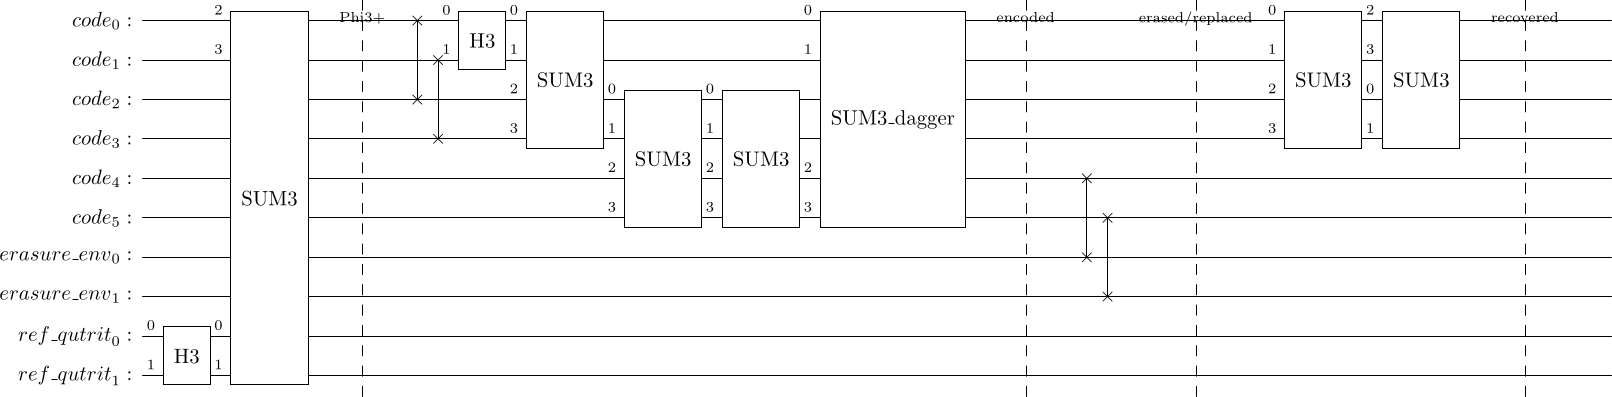

In [6]:
def build_qutrit_entanglement_channel(erased_share=ERASED_SHARE):
    if erased_share not in (1, 2, 3):
        raise ValueError("ERASED_SHARE must be 1, 2, or 3")

    code_q = QuantumRegister(6, "code")
    fresh = QuantumRegister(2, "erasure_env")
    ref = QuantumRegister(2, "ref_qutrit")
    qc = QuantumCircuit(code_q, fresh, ref)
    shares = tuple((code_q[a], code_q[b]) for a, b in SHARE_PAIRS)
    ref_pair = (ref[0], ref[1])

    # Prepare |Phi_3^+> between reference and secret share 1.
    append_qutrit_h0(qc, ref_pair)
    append_qutrit_sum(qc, ref_pair, shares[0])
    qc.barrier(label="Phi3+")

    append_qutrit_encoder(qc, shares)
    qc.barrier(label="encoded")
    
    lost_pair = shares[erased_share - 1]
    qc.swap(fresh[0], lost_pair[0])
    qc.swap(fresh[1], lost_pair[1])
    qc.barrier(label="erased/replaced")
    
    recovered_pair = append_qutrit_recovery(qc, erased_share, shares)
    qc.barrier(label="recovered")
    return qc, ref_pair, recovered_pair


channel_qc, ref_pair, recovered_pair = build_qutrit_entanglement_channel()
#print(channel_qc.draw("text", fold=180))
display(channel_qc.draw(output='latex', cregbundle=False))

In [7]:
projector_qc, fid = build_direct_phi3_projector(channel_qc, ref_pair, recovered_pair)
compiled, counts = run_counts(projector_qc, shots=SHOTS, optimization_level=OPTIMIZATION_LEVEL)
raw_fid_counts = selected_raw_marginal(counts, projector_qc, list(fid))
Fe_raw = probability_all_zero_from_distribution(raw_fid_counts, 4)
print("Backend:", BACKEND_LABEL)
print("Direct raw qutrit entanglement fidelity estimate:", Fe_raw)
print("Raw projector counts:", raw_fid_counts)

if USE_M3:
    _, quasi, m3_probs, mapping = m3_mitigated_marginal(
        compiled, counts, projector_qc, list(fid)
    )
    Fe_m3 = probability_all_zero_from_distribution(m3_probs, 4)
    print("M3 physical-qubit mapping:", mapping)
    print("Direct M3 qutrit entanglement fidelity estimate:", Fe_m3)
    print("M3 nearest probability distribution:", m3_probs)


Backend: ideal AerSimulator
Direct raw qutrit entanglement fidelity estimate: 1.0
Raw projector counts: {'0000': 10000}
M3 physical-qubit mapping: {0: 8, 1: 9, 2: 0, 3: 1}
Direct M3 qutrit entanglement fidelity estimate: 1.0
M3 nearest probability distribution: {'0000': np.float32(1.0)}


In [8]:
if RUN_TOMOGRAPHY:
    tomo = run_m3_state_tomography(
        channel_qc,
        [ref_pair[0], ref_pair[1], recovered_pair[0], recovered_pair[1]],
        phi3_statevector(),
        shots=SHOTS,
        optimization_level=OPTIMIZATION_LEVEL,
    )
    print("Tomographic raw qutrit entanglement fidelity:", tomo["raw_fidelity"])
    if USE_M3:
        print("Tomographic M3 qutrit entanglement fidelity:", tomo["m3_fidelity"])


Tomographic raw qutrit entanglement fidelity: 1.0
Tomographic M3 qutrit entanglement fidelity: 1.0
